Libraries imported successfully!
Project structure created successfully!
Customers data created!
Restaurants data created!
Drivers data created!
Orders data created!
Deliveries data created!

Raw data loaded successfully!
Customers: (1000, 5)
Restaurants: (100, 5)
Drivers: (200, 4)
Orders: (10000, 6)
Deliveries: (10000, 4)

CUSTOMERS
Rows: 1000
Columns: 5

Missing values:
customer_id          0
customer_name        0
city                 0
age                  0
registration_date    0
dtype: int64

Duplicate rows: 0

RESTAURANTS
Rows: 100
Columns: 5

Missing values:
restaurant_id      0
restaurant_name    0
city               0
cuisine            0
rating             0
dtype: int64

Duplicate rows: 0

DRIVERS
Rows: 200
Columns: 4

Missing values:
driver_id       0
driver_name     0
city            0
vehicle_type    0
dtype: int64

Duplicate rows: 0

ORDERS
Rows: 10000
Columns: 6

Missing values:
order_id         0
customer_id      0
restaurant_id    0
order_date       0
order_amount   

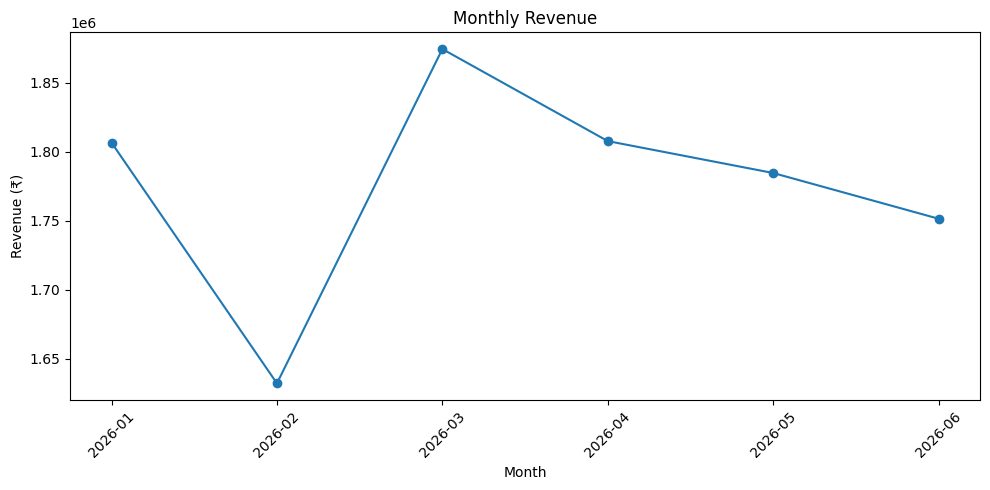

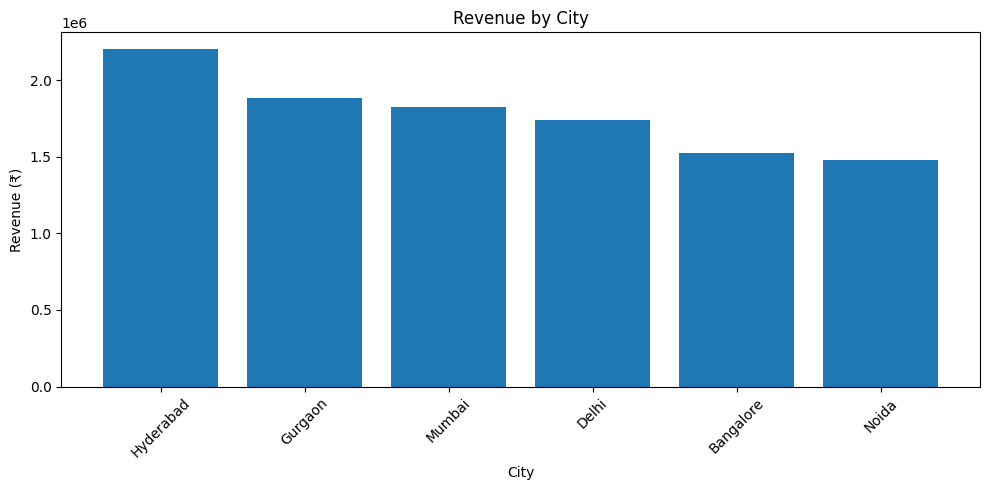

ETL pipeline file created!
SQL file created!
requirements.txt created!
.gitignore created!
README.md created!

FOOD DELIVERY DATA PLATFORM

PROJECT COMPLETED SUCCESSFULLY!

Data:
- Customers: 1,000
- Restaurants: 100
- Drivers: 200
- Orders: 10,000
- Deliveries: 10,000

Business Metrics:
- Total Revenue: ₹10,657,025.96
- Average Order Value: ₹1,323.69
- Average Delivery Time: 51.93 minutes
- Cancellation Rate: 9.65%

Technology Stack:
- Python
- Pandas
- NumPy
- SQL
- SQLite
- Matplotlib
- Git
- GitHub

Project location:
food_delivery_data_platform

READY FOR THE NEXT STAGE: GITHUB

PROJECT FILES:

food_delivery_data_platform/
    .gitignore
    README.md
    requirements.txt
    database/
        food_delivery.db
    sql/
        analysis.sql
    src/
        etl_pipeline.py
    tests/
    outputs/
        driver_performance.csv
        revenue_by_city.png
        top_customers.csv
        monthly_revenue.csv
        orders_by_cuisine.csv
        top_restaurants.csv
        cancellati

In [2]:
# ============================================================
# FOOD DELIVERY DATA PLATFORM
# End-to-End Data Engineering Portfolio Project
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries imported successfully!")


# ============================================================
# 2. CREATE PROJECT STRUCTURE
# ============================================================

project = "food_delivery_data_platform"

folders = [
    f"{project}/data/raw",
    f"{project}/data/processed",
    f"{project}/database",
    f"{project}/src",
    f"{project}/sql",
    f"{project}/tests",
    f"{project}/notebooks",
    f"{project}/outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully!")


# ============================================================
# 3. CREATE CUSTOMERS DATA
# ============================================================

num_customers = 1000

customers = pd.DataFrame({
    "customer_id": [
        f"C{i:04d}" for i in range(1, num_customers + 1)
    ],

    "customer_name": [
        f"Customer_{i}" for i in range(1, num_customers + 1)
    ],

    "city": np.random.choice(
        [
            "Delhi",
            "Gurgaon",
            "Noida",
            "Mumbai",
            "Bangalore",
            "Hyderabad"
        ],
        num_customers
    ),

    "age": np.random.randint(
        18,
        65,
        num_customers
    ),

    "registration_date": pd.date_range(
        start="2025-01-01",
        periods=num_customers,
        freq="D"
    )
})

customers.to_csv(
    f"{project}/data/raw/customers.csv",
    index=False
)

print("Customers data created!")


# ============================================================
# 4. CREATE RESTAURANTS DATA
# ============================================================

num_restaurants = 100

restaurants = pd.DataFrame({
    "restaurant_id": [
        f"R{i:03d}" for i in range(1, num_restaurants + 1)
    ],

    "restaurant_name": [
        f"Restaurant_{i}" for i in range(1, num_restaurants + 1)
    ],

    "city": np.random.choice(
        [
            "Delhi",
            "Gurgaon",
            "Noida",
            "Mumbai",
            "Bangalore",
            "Hyderabad"
        ],
        num_restaurants
    ),

    "cuisine": np.random.choice(
        [
            "Indian",
            "Chinese",
            "Italian",
            "Mexican",
            "Fast Food",
            "South Indian"
        ],
        num_restaurants
    ),

    "rating": np.round(
        np.random.uniform(
            2.5,
            5.0,
            num_restaurants
        ),
        1
    )
})

restaurants.to_csv(
    f"{project}/data/raw/restaurants.csv",
    index=False
)

print("Restaurants data created!")


# ============================================================
# 5. CREATE DRIVERS DATA
# ============================================================

num_drivers = 200

drivers = pd.DataFrame({
    "driver_id": [
        f"D{i:04d}" for i in range(1, num_drivers + 1)
    ],

    "driver_name": [
        f"Driver_{i}" for i in range(1, num_drivers + 1)
    ],

    "city": np.random.choice(
        [
            "Delhi",
            "Gurgaon",
            "Noida",
            "Mumbai",
            "Bangalore",
            "Hyderabad"
        ],
        num_drivers
    ),

    "vehicle_type": np.random.choice(
        [
            "Bike",
            "Scooter",
            "Car"
        ],
        num_drivers
    )
})

drivers.to_csv(
    f"{project}/data/raw/drivers.csv",
    index=False
)

print("Drivers data created!")


# ============================================================
# 6. CREATE ORDERS DATA
# ============================================================

num_orders = 10000

order_dates = pd.date_range(
    start="2026-01-01",
    end="2026-06-30",
    periods=num_orders
)

orders = pd.DataFrame({
    "order_id": [
        f"O{i:05d}" for i in range(1, num_orders + 1)
    ],

    "customer_id": np.random.choice(
        customers["customer_id"],
        num_orders
    ),

    "restaurant_id": np.random.choice(
        restaurants["restaurant_id"],
        num_orders
    ),

    "order_date": order_dates,

    "order_amount": np.round(
        np.random.uniform(
            100,
            2500,
            num_orders
        ),
        2
    ),

    "order_status": np.random.choice(
        [
            "Delivered",
            "Cancelled",
            "Pending"
        ],
        num_orders,
        p=[
            0.80,
            0.10,
            0.10
        ]
    )
})

orders.to_csv(
    f"{project}/data/raw/orders.csv",
    index=False
)

print("Orders data created!")


# ============================================================
# 7. CREATE DELIVERIES DATA
# ============================================================

deliveries = orders[
    ["order_id"]
].copy()

deliveries["driver_id"] = np.random.choice(
    drivers["driver_id"],
    len(deliveries)
)

deliveries["delivery_time_minutes"] = np.random.randint(
    15,
    90,
    len(deliveries)
)

deliveries["delivery_status"] = np.where(
    orders["order_status"] == "Delivered",
    "Completed",
    orders["order_status"]
)

deliveries.to_csv(
    f"{project}/data/raw/deliveries.csv",
    index=False
)

print("Deliveries data created!")


# ============================================================
# 8. LOAD RAW DATA
# ============================================================

customers = pd.read_csv(
    f"{project}/data/raw/customers.csv"
)

restaurants = pd.read_csv(
    f"{project}/data/raw/restaurants.csv"
)

drivers = pd.read_csv(
    f"{project}/data/raw/drivers.csv"
)

orders = pd.read_csv(
    f"{project}/data/raw/orders.csv"
)

deliveries = pd.read_csv(
    f"{project}/data/raw/deliveries.csv"
)

print()
print("Raw data loaded successfully!")
print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Drivers:", drivers.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)


# ============================================================
# 9. DATA QUALITY CHECK
# ============================================================

def data_quality_report(df, name):

    print()
    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

    print()
    print("Missing values:")
    print(df.isnull().sum())

    print()
    print("Duplicate rows:", df.duplicated().sum())


data_quality_report(
    customers,
    "CUSTOMERS"
)

data_quality_report(
    restaurants,
    "RESTAURANTS"
)

data_quality_report(
    drivers,
    "DRIVERS"
)

data_quality_report(
    orders,
    "ORDERS"
)

data_quality_report(
    deliveries,
    "DELIVERIES"
)


# ============================================================
# 10. DATA CLEANING
# ============================================================

customers = customers.drop_duplicates()

restaurants = restaurants.drop_duplicates()

drivers = drivers.drop_duplicates()

orders = orders.drop_duplicates()

deliveries = deliveries.drop_duplicates()

customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

orders["order_amount"] = (
    orders["order_amount"].abs()
)

restaurants["rating"] = (
    restaurants["rating"]
    .fillna(restaurants["rating"].mean())
)

print()
print("Data cleaning completed successfully!")


# ============================================================
# 11. CREATE MAIN DATASET
# ============================================================

food_delivery = (
    orders
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        restaurants,
        on="restaurant_id",
        how="left"
    )
    .merge(
        deliveries,
        on="order_id",
        how="left"
    )
    .merge(
        drivers,
        on="driver_id",
        how="left",
        suffixes=(
            "",
            "_driver"
        )
    )
)

print()
print(
    "Final dataset shape:",
    food_delivery.shape
)


# ============================================================
# 12. SAVE PROCESSED DATA
# ============================================================

food_delivery.to_csv(
    f"{project}/data/processed/food_delivery_processed.csv",
    index=False
)

print("Processed data saved!")


# ============================================================
# 13. BUSINESS METRICS
# ============================================================

delivered_orders = food_delivery[
    food_delivery["order_status"] == "Delivered"
].copy()

total_orders = len(food_delivery)

delivered_count = len(
    delivered_orders
)

cancelled_count = len(
    food_delivery[
        food_delivery["order_status"] == "Cancelled"
    ]
)

pending_count = len(
    food_delivery[
        food_delivery["order_status"] == "Pending"
    ]
)

total_revenue = (
    delivered_orders["order_amount"].sum()
)

average_order_value = (
    delivered_orders["order_amount"].mean()
)

average_delivery_time = (
    delivered_orders[
        "delivery_time_minutes"
    ].mean()
)

cancellation_rate = (
    cancelled_count
    / total_orders
    * 100
)

print()
print("=" * 60)
print("FOOD DELIVERY BUSINESS METRICS")
print("=" * 60)

print(
    f"Total Orders: {total_orders:,}"
)

print(
    f"Delivered Orders: {delivered_count:,}"
)

print(
    f"Cancelled Orders: {cancelled_count:,}"
)

print(
    f"Pending Orders: {pending_count:,}"
)

print(
    f"Total Revenue: ₹{total_revenue:,.2f}"
)

print(
    f"Average Order Value: ₹{average_order_value:,.2f}"
)

print(
    f"Average Delivery Time: "
    f"{average_delivery_time:.2f} minutes"
)

print(
    f"Cancellation Rate: "
    f"{cancellation_rate:.2f}%"
)


# ============================================================
# 14. REVENUE BY CITY
# ============================================================

revenue_by_city = (
    delivered_orders
    .groupby("city")
    .agg(
        total_revenue=(
            "order_amount",
            "sum"
        ),

        total_orders=(
            "order_id",
            "count"
        ),

        average_order_value=(
            "order_amount",
            "mean"
        )
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print()
print("=" * 60)
print("REVENUE BY CITY")
print("=" * 60)

print(
    revenue_by_city
)


# ============================================================
# 15. TOP RESTAURANTS
# ============================================================

top_restaurants = (
    delivered_orders
    .groupby(
        [
            "restaurant_id",
            "restaurant_name",
            "cuisine"
        ]
    )
    .agg(
        total_revenue=(
            "order_amount",
            "sum"
        ),

        total_orders=(
            "order_id",
            "count"
        ),

        average_order_value=(
            "order_amount",
            "mean"
        )
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(10)
)

print()
print("=" * 60)
print("TOP 10 RESTAURANTS")
print("=" * 60)

print(
    top_restaurants
)


# ============================================================
# 16. TOP CUSTOMERS
# ============================================================

top_customers = (
    delivered_orders
    .groupby(
        [
            "customer_id",
            "customer_name",
            "city"
        ]
    )
    .agg(
        total_spending=(
            "order_amount",
            "sum"
        ),

        number_of_orders=(
            "order_id",
            "count"
        ),

        average_order_value=(
            "order_amount",
            "mean"
        )
    )
    .sort_values(
        "total_spending",
        ascending=False
    )
    .head(10)
)

print()
print("=" * 60)
print("TOP 10 CUSTOMERS")
print("=" * 60)

print(
    top_customers
)


# ============================================================
# 17. ORDERS BY CUISINE
# ============================================================

orders_by_cuisine = (
    delivered_orders
    .groupby("cuisine")
    .agg(
        total_orders=(
            "order_id",
            "count"
        ),

        total_revenue=(
            "order_amount",
            "sum"
        ),

        average_order_value=(
            "order_amount",
            "mean"
        )
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print()
print("=" * 60)
print("ORDERS BY CUISINE")
print("=" * 60)

print(
    orders_by_cuisine
)


# ============================================================
# 18. CANCELLATION ANALYSIS
# ============================================================

cancellation_analysis = (
    food_delivery
    .groupby("city")
    .agg(
        total_orders=(
            "order_id",
            "count"
        ),

        cancelled_orders=(
            "order_status",
            lambda x: (
                x == "Cancelled"
            ).sum()
        )
    )
)

cancellation_analysis[
    "cancellation_rate"
] = (
    cancellation_analysis[
        "cancelled_orders"
    ]
    / cancellation_analysis[
        "total_orders"
    ]
    * 100
)

cancellation_analysis = (
    cancellation_analysis
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)

print()
print("=" * 60)
print("CANCELLATION ANALYSIS")
print("=" * 60)

print(
    cancellation_analysis
)


# ============================================================
# 19. MONTHLY REVENUE
# ============================================================

delivered_orders["month"] = (
    delivered_orders[
        "order_date"
    ]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    delivered_orders
    .groupby("month")
    .agg(
        total_revenue=(
            "order_amount",
            "sum"
        ),

        total_orders=(
            "order_id",
            "count"
        ),

        average_order_value=(
            "order_amount",
            "mean"
        )
    )
)

print()
print("=" * 60)
print("MONTHLY REVENUE")
print("=" * 60)

print(
    monthly_revenue
)


# ============================================================
# 20. DRIVER PERFORMANCE
# ============================================================

driver_performance = (
    delivered_orders
    .groupby(
        [
            "driver_id",
            "driver_name"
        ]
    )
    .agg(
        total_deliveries=(
            "order_id",
            "count"
        ),

        average_delivery_time=(
            "delivery_time_minutes",
            "mean"
        )
    )
    .sort_values(
        "total_deliveries",
        ascending=False
    )
)

print()
print("=" * 60)
print("TOP DRIVERS")
print("=" * 60)

print(
    driver_performance.head(10)
)


# ============================================================
# 21. CREATE SQLITE DATABASE
# ============================================================

database_path = (
    f"{project}/database/"
    "food_delivery.db"
)

connection = sqlite3.connect(
    database_path
)

customers.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

restaurants.to_sql(
    "restaurants",
    connection,
    if_exists="replace",
    index=False
)

drivers.to_sql(
    "drivers",
    connection,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    connection,
    if_exists="replace",
    index=False
)

deliveries.to_sql(
    "deliveries",
    connection,
    if_exists="replace",
    index=False
)

print()
print("SQLite database created successfully!")


# ============================================================
# 22. SQL ANALYSIS
# ============================================================

query = """
SELECT
    r.city,
    COUNT(o.order_id) AS total_orders,
    SUM(o.order_amount) AS total_revenue,
    AVG(o.order_amount) AS average_order_value
FROM orders o
JOIN restaurants r
    ON o.restaurant_id = r.restaurant_id
WHERE o.order_status = 'Delivered'
GROUP BY r.city
ORDER BY total_revenue DESC;
"""

city_analysis_sql = pd.read_sql_query(
    query,
    connection
)

print()
print("=" * 60)
print("SQL: CITY ANALYSIS")
print("=" * 60)

print(
    city_analysis_sql
)


# ============================================================
# 23. SQL: TOP RESTAURANTS
# ============================================================

query = """
SELECT
    r.restaurant_id,
    r.restaurant_name,
    r.cuisine,
    COUNT(o.order_id) AS total_orders,
    SUM(o.order_amount) AS total_revenue
FROM orders o
JOIN restaurants r
    ON o.restaurant_id = r.restaurant_id
WHERE o.order_status = 'Delivered'
GROUP BY
    r.restaurant_id,
    r.restaurant_name,
    r.cuisine
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_restaurants_sql = pd.read_sql_query(
    query,
    connection
)

print()
print("=" * 60)
print("SQL: TOP RESTAURANTS")
print("=" * 60)

print(
    top_restaurants_sql
)


# ============================================================
# 24. EXPORT ANALYTICAL OUTPUTS
# ============================================================

revenue_by_city.to_csv(
    f"{project}/outputs/revenue_by_city.csv"
)

top_restaurants.to_csv(
    f"{project}/outputs/top_restaurants.csv"
)

top_customers.to_csv(
    f"{project}/outputs/top_customers.csv"
)

orders_by_cuisine.to_csv(
    f"{project}/outputs/orders_by_cuisine.csv"
)

cancellation_analysis.to_csv(
    f"{project}/outputs/cancellation_analysis.csv"
)

monthly_revenue.to_csv(
    f"{project}/outputs/monthly_revenue.csv"
)

driver_performance.to_csv(
    f"{project}/outputs/driver_performance.csv"
)

print()
print("All analytical outputs exported successfully!")


# ============================================================
# 25. CREATE REVENUE CHART
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    monthly_revenue.index,
    monthly_revenue["total_revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Revenue (₹)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    f"{project}/outputs/monthly_revenue.png"
)

plt.show()


# ============================================================
# 26. CREATE CITY REVENUE CHART
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    revenue_by_city.index,
    revenue_by_city["total_revenue"]
)

plt.title(
    "Revenue by City"
)

plt.xlabel(
    "City"
)

plt.ylabel(
    "Revenue (₹)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    f"{project}/outputs/revenue_by_city.png"
)

plt.show()


# ============================================================
# 27. CREATE ETL PIPELINE FILE
# ============================================================

etl_code = '''
import pandas as pd


def load_data():

    customers = pd.read_csv(
        "data/raw/customers.csv"
    )

    restaurants = pd.read_csv(
        "data/raw/restaurants.csv"
    )

    drivers = pd.read_csv(
        "data/raw/drivers.csv"
    )

    orders = pd.read_csv(
        "data/raw/orders.csv"
    )

    deliveries = pd.read_csv(
        "data/raw/deliveries.csv"
    )

    return (
        customers,
        restaurants,
        drivers,
        orders,
        deliveries
    )


def clean_data(
    customers,
    restaurants,
    drivers,
    orders,
    deliveries
):

    customers = customers.drop_duplicates()

    restaurants = restaurants.drop_duplicates()

    drivers = drivers.drop_duplicates()

    orders = orders.drop_duplicates()

    deliveries = deliveries.drop_duplicates()

    customers["registration_date"] = (
        pd.to_datetime(
            customers["registration_date"]
        )
    )

    orders["order_date"] = (
        pd.to_datetime(
            orders["order_date"]
        )
    )

    orders["order_amount"] = (
        orders["order_amount"].abs()
    )

    restaurants["rating"] = (
        restaurants["rating"]
        .fillna(
            restaurants["rating"].mean()
        )
    )

    return (
        customers,
        restaurants,
        drivers,
        orders,
        deliveries
    )


def create_dataset(
    customers,
    restaurants,
    drivers,
    orders,
    deliveries
):

    food_delivery = (
        orders
        .merge(
            customers,
            on="customer_id",
            how="left"
        )
        .merge(
            restaurants,
            on="restaurant_id",
            how="left"
        )
        .merge(
            deliveries,
            on="order_id",
            how="left"
        )
        .merge(
            drivers,
            on="driver_id",
            how="left",
            suffixes=(
                "",
                "_driver"
            )
        )
    )

    return food_delivery


def main():

    print("Starting ETL pipeline...")

    data = load_data()

    data = clean_data(*data)

    food_delivery = create_dataset(*data)

    food_delivery.to_csv(
        "data/processed/"
        "food_delivery_processed.csv",
        index=False
    )

    print(
        "ETL pipeline completed successfully!"
    )


if __name__ == "__main__":
    main()
'''

with open(
    f"{project}/src/etl_pipeline.py",
    "w"
) as file:

    file.write(
        etl_code.strip()
    )

print("ETL pipeline file created!")


# ============================================================
# 28. CREATE SQL FILE
# ============================================================

sql_code = '''
-- FOOD DELIVERY DATA PLATFORM
-- SQL ANALYSIS


-- Total orders

SELECT
    COUNT(*) AS total_orders
FROM orders;


-- Total revenue

SELECT
    SUM(order_amount) AS total_revenue
FROM orders
WHERE order_status = 'Delivered';


-- Average order value

SELECT
    AVG(order_amount) AS average_order_value
FROM orders
WHERE order_status = 'Delivered';


-- Orders by status

SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status;


-- Revenue by restaurant

SELECT
    restaurant_id,
    COUNT(order_id) AS total_orders,
    SUM(order_amount) AS total_revenue
FROM orders
WHERE order_status = 'Delivered'
GROUP BY restaurant_id
ORDER BY total_revenue DESC;


-- Revenue by month

SELECT
    strftime(
        '%Y-%m',
        order_date
    ) AS month,

    COUNT(order_id) AS total_orders,

    SUM(order_amount) AS total_revenue

FROM orders

WHERE order_status = 'Delivered'

GROUP BY month

ORDER BY month;
'''

with open(
    f"{project}/sql/analysis.sql",
    "w"
) as file:

    file.write(
        sql_code.strip()
    )

print("SQL file created!")


# ============================================================
# 29. CREATE REQUIREMENTS FILE
# ============================================================

requirements = """
pandas
numpy
matplotlib
jupyter
"""

with open(
    f"{project}/requirements.txt",
    "w"
) as file:

    file.write(
        requirements.strip()
    )

print("requirements.txt created!")


# ============================================================
# 30. CREATE GITIGNORE FILE
# ============================================================

gitignore = """
__pycache__/
*.pyc
.ipynb_checkpoints/
.env
*.db
.DS_Store
"""

with open(
    f"{project}/.gitignore",
    "w"
) as file:

    file.write(
        gitignore.strip()
    )

print(".gitignore created!")


# ============================================================
# 31. CREATE README FILE
# ============================================================

readme = """
# Food Delivery Data Platform

## Project Overview

This project is an end-to-end data engineering project that simulates a food delivery company's data platform.

The goal is to transform raw operational data into reliable analytical data.

## Business Problem

A food delivery company generates large amounts of data from customers, restaurants, drivers, orders, and deliveries.

The objective is to build a data pipeline that can ingest, clean, transform, store, and analyze this data.

## Data Pipeline

Raw Data
    |
    v
Python / Pandas
    |
    v
Data Cleaning
    |
    v
Data Transformation
    |
    v
SQLite Database
    |
    v
SQL Analytics
    |
    v
Reports and Visualizations

## Technologies

- Python
- Pandas
- NumPy
- SQL
- SQLite
- Matplotlib
- Jupyter Notebook
- Git
- GitHub

## Data Sources

The project uses simulated datasets for:

- Customers
- Restaurants
- Drivers
- Orders
- Deliveries

## Key Metrics

The project calculates:

- Total orders
- Delivered orders
- Cancelled orders
- Pending orders
- Total revenue
- Average order value
- Average delivery time
- Cancellation rate
- Revenue by city
- Top restaurants
- Top customers
- Orders by cuisine
- Monthly revenue
- Driver performance

## Project Structure

food_delivery_data_platform/

    data/
        raw/
        processed/

    database/

    notebooks/

    outputs/

    sql/

    src/

    tests/

    .gitignore
    README.md
    requirements.txt

## Future Improvements

- PostgreSQL
- Apache Airflow
- dbt
- Docker
- Apache Kafka
- Apache Spark
- AWS S3
- AWS Redshift
- Power BI
- Data quality testing
- CI/CD

## Author

Data Engineering Portfolio Project
"""

with open(
    f"{project}/README.md",
    "w"
) as file:

    file.write(
        readme.strip()
    )

print("README.md created!")


# ============================================================
# 32. CREATE PROJECT SUMMARY
# ============================================================

print()
print("=" * 70)
print("FOOD DELIVERY DATA PLATFORM")
print("=" * 70)

print()
print("PROJECT COMPLETED SUCCESSFULLY!")

print()
print("Data:")
print(f"- Customers: {len(customers):,}")
print(f"- Restaurants: {len(restaurants):,}")
print(f"- Drivers: {len(drivers):,}")
print(f"- Orders: {len(orders):,}")
print(f"- Deliveries: {len(deliveries):,}")

print()
print("Business Metrics:")
print(f"- Total Revenue: ₹{total_revenue:,.2f}")
print(f"- Average Order Value: ₹{average_order_value:,.2f}")
print(
    f"- Average Delivery Time: "
    f"{average_delivery_time:.2f} minutes"
)
print(
    f"- Cancellation Rate: "
    f"{cancellation_rate:.2f}%"
)

print()
print("Technology Stack:")
print("- Python")
print("- Pandas")
print("- NumPy")
print("- SQL")
print("- SQLite")
print("- Matplotlib")
print("- Git")
print("- GitHub")

print()
print("Project location:")
print(project)

print()
print("=" * 70)
print("READY FOR THE NEXT STAGE: GITHUB")
print("=" * 70)


# ============================================================
# 33. DISPLAY PROJECT FILES
# ============================================================

print()
print("PROJECT FILES:")
print()

for root, directories, files in os.walk(project):

    level = root.replace(
        project,
        ""
    ).count(os.sep)

    indentation = "    " * level

    print(
        f"{indentation}{os.path.basename(root)}/"
    )

    for file in files:

        print(
            f"{indentation}    {file}"
        )


# ============================================================
# 34. CLOSE DATABASE CONNECTION
# ============================================================

connection.close()

print()
print("Database connection closed.")
print("All tasks completed successfully! 🚀")

In [3]:
import shutil

shutil.make_archive(
    "food_delivery_data_platform",
    "zip",
    "food_delivery_data_platform"
)

print("Project ZIP created successfully!")

Project ZIP created successfully!
